In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [2]:
df_cc = pd.read_csv('data/raw/creditcard.csv')
print("Shape:", df_cc.shape)
df_cc.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("=== MISSING VALUES ===")
print(df_cc.isnull().sum().sum(), "total missing values")
print("\n=== DUPLICATES ===")
print(df_cc.duplicated().sum(), "duplicate rows")
print("\n=== DATA TYPES ===")
print(df_cc.dtypes.value_counts())

=== MISSING VALUES ===
0 total missing values

=== DUPLICATES ===
1081 duplicate rows

=== DATA TYPES ===
float64    30
int64       1
Name: count, dtype: int64


=== CLASS DISTRIBUTION ===
Legitimate (0): 284,315 (99.8273%)
Fraud (1):      492 (0.1727%)


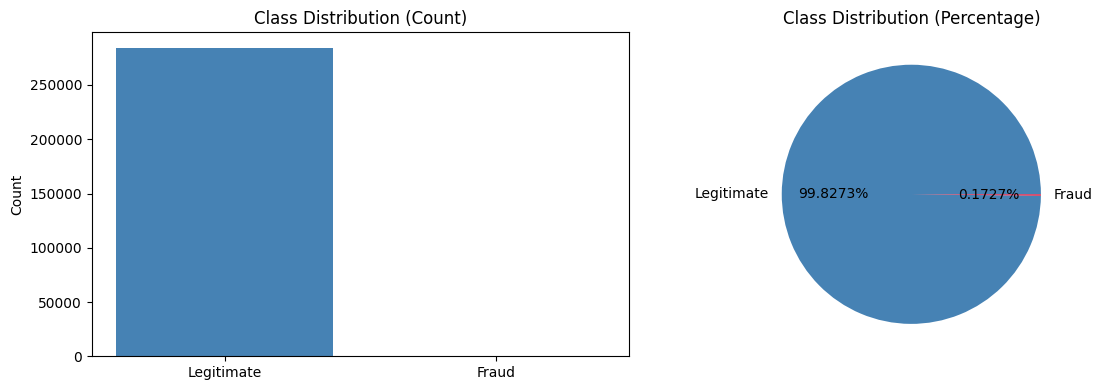

In [4]:
fraud_counts = df_cc['Class'].value_counts()
fraud_pct = df_cc['Class'].value_counts(normalize=True) * 100

print("=== CLASS DISTRIBUTION ===")
print(f"Legitimate (0): {fraud_counts[0]:,} ({fraud_pct[0]:.4f}%)")
print(f"Fraud (1):      {fraud_counts[1]:,} ({fraud_pct[1]:.4f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Count')

axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.4f%%', colors=['steelblue', 'crimson'])
axes[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.savefig('data/processed/class_distribution_creditcard.png', dpi=150, bbox_inches='tight')
plt.show()

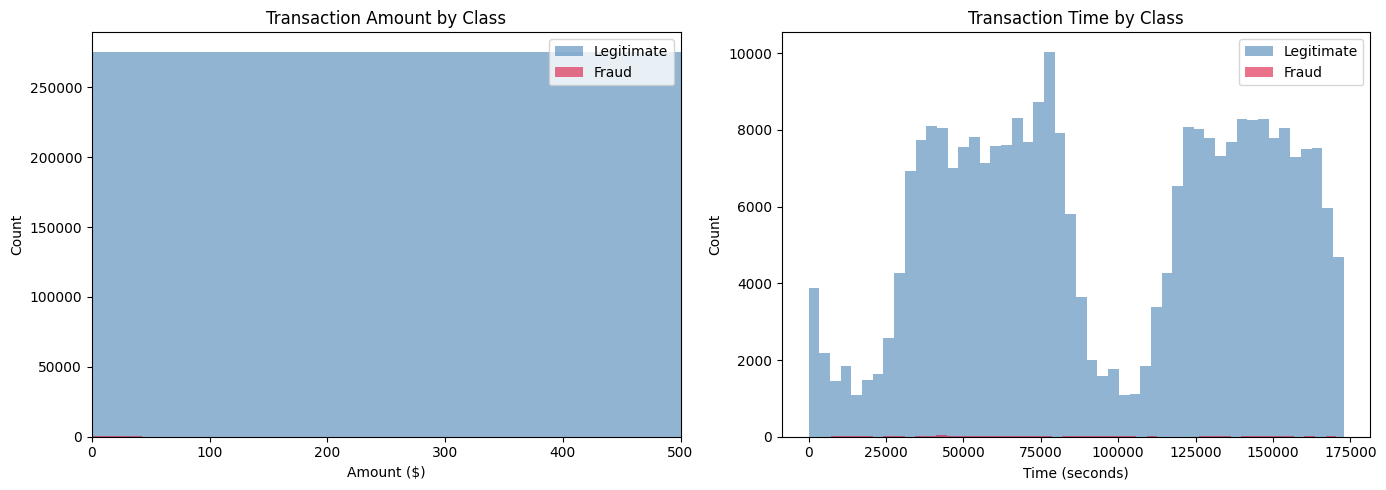

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_cc[df_cc['Class']==0]['Amount'], bins=50, alpha=0.6, color='steelblue', label='Legitimate')
axes[0].hist(df_cc[df_cc['Class']==1]['Amount'], bins=50, alpha=0.6, color='crimson', label='Fraud')
axes[0].set_title('Transaction Amount by Class')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 500)
axes[0].legend()

axes[1].hist(df_cc[df_cc['Class']==0]['Time'], bins=50, alpha=0.6, color='steelblue', label='Legitimate')
axes[1].hist(df_cc[df_cc['Class']==1]['Time'], bins=50, alpha=0.6, color='crimson', label='Fraud')
axes[1].set_title('Transaction Time by Class')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/processed/creditcard_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

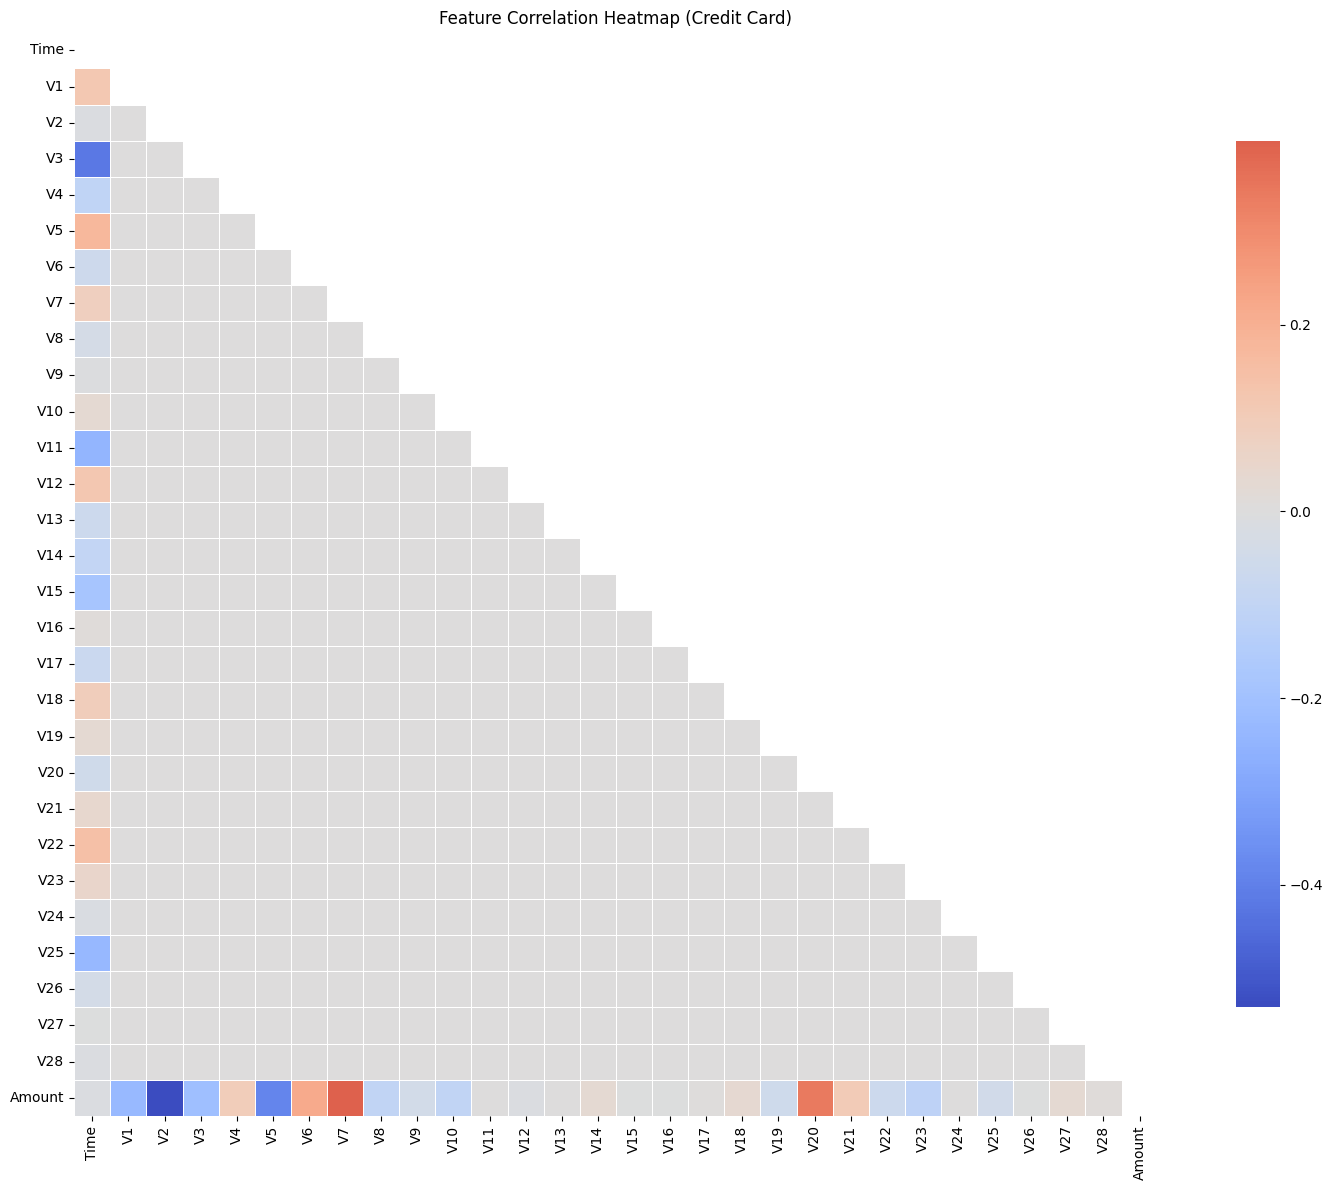

In [6]:
plt.figure(figsize=(16, 12))
corr = df_cc.drop('Class', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap (Credit Card)')
plt.tight_layout()
plt.savefig('data/processed/creditcard_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
df_cc_clean = df_cc.drop_duplicates()
print(f"Removed {len(df_cc) - len(df_cc_clean)} duplicates")
print("Clean shape:", df_cc_clean.shape)

Removed 1081 duplicates
Clean shape: (283726, 31)


In [8]:
X = df_cc_clean.drop('Class', axis=1)
y = df_cc_clean['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts())

Train size: (226980, 30)
Test size: (56746, 30)

Train class distribution:
Class
0    226602
1       378
Name: count, dtype: int64


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")
print("X_train_scaled shape:", X_train_scaled.shape)

Scaling done
X_train_scaled shape: (226980, 30)


Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


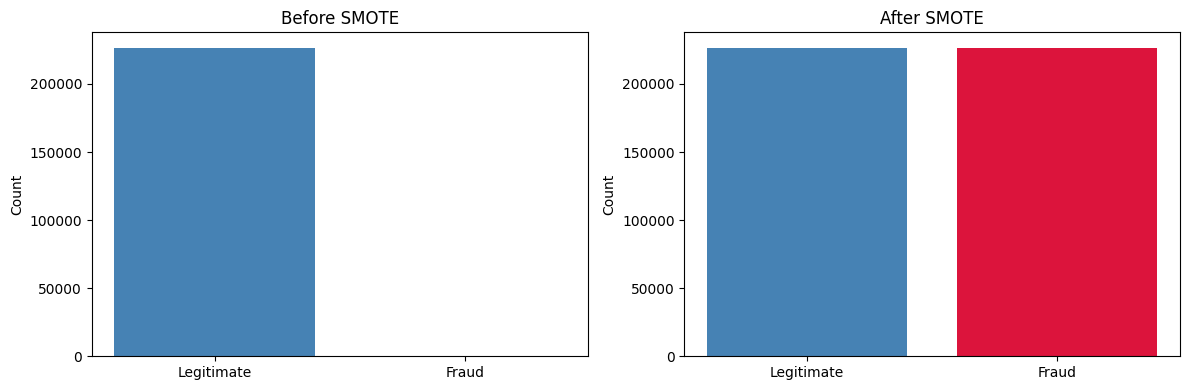

In [10]:
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Legitimate', 'Fraud'], y_train.value_counts().values, color=['steelblue', 'crimson'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

axes[1].bar(['Legitimate', 'Fraud'], pd.Series(y_train_smote).value_counts().values, color=['steelblue', 'crimson'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('data/processed/smote_creditcard.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
import pickle

X_train_smote_df = pd.DataFrame(X_train_smote, columns=X.columns)
y_train_smote_df = pd.Series(y_train_smote, name='Class')

X_train_smote_df.to_csv('data/processed/X_train_creditcard.csv', index=False)
y_train_smote_df.to_csv('data/processed/y_train_creditcard.csv', index=False)

X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
X_test_df.to_csv('data/processed/X_test_creditcard.csv', index=False)
y_test.to_csv('data/processed/y_test_creditcard.csv', index=False)

with open('models/scaler_creditcard.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("All creditcard processed data saved!")
print("X_train after SMOTE:", X_train_smote_df.shape)
print("X_test:", X_test_df.shape)

All creditcard processed data saved!
X_train after SMOTE: (453204, 30)
X_test: (56746, 30)
